In [279]:
import pandas as pd

# **`PHASE 1: Data Cleaning & Preprocessing`**

In [281]:
df = pd.read_csv("/content/saas_funnel.csv")

In [282]:
df.head()

,user_id,signup_date,acquisition_channel,device_type,country,plan_type,funnel_stage,session_count,session_duration_min,features_used,support_tickets,user_feedback,satisfaction_score,upgraded,churned,onboarding_completed,bugs_reported,referral_count,trial_days_left,last_active_days
0,1,2025-10-17,Paid,Mobile,Canada,Free,Sign-up,3.0,21.0,0.0,0.0,Still evaluating whether premium is worth it,3.6,0,1,0,1.0,0.0,0.0,NaN
1,2,2025-06-24,Organic,Mobile,India,Free,Onboarding,3.0,21.0,2.0,1.0,Average experience so far,3.6,0,1,1,2.0,0.0,0.0,13.0
2,3,2025-08-02,Referral,Mobile,USA,Free,Sign-up,3.0,13.0,0.0,0.0,Decent but not great,2.8,0,1,0,0.0,0.0,0.0,4.0
3,4,2025-02-04,Organic,Mobile,UK,Free,Landing,1.0,8.0,0.0,0.0,Data sync is unreliable,1.0,0,1,0,0.0,0.0,0.0,5.0
4,5,2025-08-09,Referral,Mobile,USA,Basic,Onboarding,7.0,42.0,3.0,0.0,Good enough for my use case,3.5,0,0,1,0.0,0.0,NaN,5.0


In [283]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               6000 non-null   int64  
 1   signup_date           6000 non-null   object 
 2   acquisition_channel   5949 non-null   object 
 3   device_type           6000 non-null   object 
 4   country               6000 non-null   object 
 5   plan_type             6000 non-null   object 
 6   funnel_stage          6000 non-null   object 
 7   session_count         5852 non-null   float64
 8   session_duration_min  5842 non-null   float64
 9   features_used         5843 non-null   float64
 10  support_tickets       5844 non-null   float64
 11  user_feedback         6000 non-null   object 
 12  satisfaction_score    5845 non-null   float64
 13  upgraded              6000 non-null   int64  
 14  churned               6000 non-null   int64  
 15  onboarding_completed 

In [284]:
df.isnull().sum()

,0
user_id,0
signup_date,0
acquisition_channel,51
device_type,0
country,0
plan_type,0
funnel_stage,0
session_count,148
session_duration_min,158
features_used,157


In [285]:
df.describe()

,user_id,session_count,session_duration_min,features_used,support_tickets,satisfaction_score,upgraded,churned,onboarding_completed,bugs_reported,referral_count,trial_days_left,last_active_days
count,6000.000000,5852.000000,5842.000000,5843.000000,5844.000000,5845.000000,6000.000000,6000.000000,6000.000000,5857.000000,5843.000000,5850.000000,5836.000000
mean,3000.500000,5.631237,34.418692,2.963033,0.298939,3.054816,0.112333,0.808667,0.523833,0.409937,0.160876,0.586325,7.168951
std,1732.195139,4.993145,29.977752,4.221325,0.574242,1.039713,0.315802,0.393384,0.499473,0.665651,0.411404,2.252291,5.578749
min,1.000000,1.000000,5.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,1500.750000,2.000000,13.000000,0.000000,0.000000,2.300000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,3000.500000,4.000000,24.000000,1.000000,0.000000,3.100000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,6.000000
75%,4500.250000,7.000000,42.000000,4.000000,0.000000,3.800000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,9.000000
max,6000.000000,24.000000,149.000000,19.000000,6.000000,5.000000,1.000000,1.000000,1.000000,5.000000,3.000000,14.000000,29.000000


# **`Preprosessing`**

Firstly observed the `signup_date` column which is showing a wrong data type of object, let handel it.

In [286]:
df['signup_date'] = pd.to_datetime(df['signup_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               6000 non-null   int64         
 1   signup_date           6000 non-null   datetime64[ns]
 2   acquisition_channel   5949 non-null   object        
 3   device_type           6000 non-null   object        
 4   country               6000 non-null   object        
 5   plan_type             6000 non-null   object        
 6   funnel_stage          6000 non-null   object        
 7   session_count         5852 non-null   float64       
 8   session_duration_min  5842 non-null   float64       
 9   features_used         5843 non-null   float64       
 10  support_tickets       5844 non-null   float64       
 11  user_feedback         6000 non-null   object        
 12  satisfaction_score    5845 non-null   float64       
 13  upgraded          

lets check for any duplicate values

In [287]:
print(f"Shape of DataFrame before dropping duplicates: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"Shape of DataFrame after dropping duplicates: {df.shape}")

Shape of DataFrame before dropping duplicates: (6000, 20)
Shape of DataFrame after dropping duplicates: (6000, 20)


now lets handel missing values in some columns like:
- `session_count`,
- `session_duration_min`,
- `features_used`,
- `satisfaction_score`,
- `support_tickets`,
- `satisfaction_score`,
etc

In [288]:
columns_to_impute_numerical = ['session_count','session_duration_min','features_used', 'support_tickets', 'satisfaction_score', 'bugs_reported', 'referral_count', 'trial_days_left', 'last_active_days']

for col in columns_to_impute_numerical:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"Missing values in '{col}' imputed with median: {median_val}")

print("\nMissing values after all imputations:")
print(df.isnull().sum())

Missing values in 'session_count' imputed with median: 4.0
Missing values in 'session_duration_min' imputed with median: 24.0
Missing values in 'features_used' imputed with median: 1.0
Missing values in 'support_tickets' imputed with median: 0.0
Missing values in 'satisfaction_score' imputed with median: 3.1
Missing values in 'bugs_reported' imputed with median: 0.0
Missing values in 'referral_count' imputed with median: 0.0
Missing values in 'trial_days_left' imputed with median: 0.0
Missing values in 'last_active_days' imputed with median: 6.0

Missing values after all imputations:
user_id                  0
signup_date              0
acquisition_channel     51
device_type              0
country                  0
plan_type                0
funnel_stage             0
session_count            0
session_duration_min     0
features_used            0
support_tickets          0
user_feedback            0
satisfaction_score       0
upgraded                 0
churned                  0
onbo

/tmp/ipykernel_3670/2738234020.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [289]:
df['acquisition_channel'].fillna(df['acquisition_channel'].mode()[0], inplace=True)

/tmp/ipykernel_3670/627790276.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [290]:
df.isnull().sum()

,0
user_id,0
signup_date,0
acquisition_channel,0
device_type,0
country,0
plan_type,0
funnel_stage,0
session_count,0
session_duration_min,0
features_used,0


In [291]:
df.duplicated().sum()

np.int64(0)

## **`Save Clean Dataset`**

In [292]:
df.to_csv("cleaned_saas_data.csv", index=False)

# **`PHASE 2: Exploratory Data Analysis(EDA)`**

In [293]:
df = pd.read_csv("/content/cleaned_saas_data.csv", parse_dates=['signup_date'])

### **`Funnel Stage Distribution`**

Let's analyze the distribution of users across different funnel stages. We'll visualize this using both a bar chart for raw counts and a funnel chart to show the progression and drop-off rates.

In [294]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [295]:
funnel_order = [
    'Landing',
    'Sign-up',
    'Onboarding',
    'First Feature Use',
    'Upgrade'
]

funnel_counts = []

for stage in funnel_order:

    if stage == 'Landing':
        count = len(df)

    elif stage == 'Sign-up':
        count = len(df[df['funnel_stage'].isin(
            ['Sign-up', 'Onboarding', 'First Feature Use', 'Upgrade']
        )])

    elif stage == 'Onboarding':
        count = len(df[df['funnel_stage'].isin(
            ['Onboarding', 'First Feature Use', 'Upgrade']
        )])

    elif stage == 'First Feature Use':
        count = len(df[df['funnel_stage'].isin(
            ['First Feature Use', 'Upgrade']
        )])

    elif stage == 'Upgrade':
        count = len(df[df['funnel_stage'] == 'Upgrade'])

    funnel_counts.append(count)

funnel_df = pd.DataFrame({
    'funnel_stage': funnel_order,
    'count': funnel_counts
})

# Percentage relative to landing users
funnel_df['percentage'] = (
    funnel_df['count'] /
    funnel_df['count'].iloc[0]
) * 100

display(funnel_df)

,funnel_stage,count,percentage
0,Landing,6000,100.000000
1,Sign-up,4805,80.083333
2,Onboarding,3143,52.383333
3,First Feature Use,1729,28.816667
4,Upgrade,674,11.233333


In [296]:
fig = px.funnel(
    funnel_df,
    x='count',
    y='funnel_stage',
    title='User Funnel Progression'
)

fig.show()

#### Bar Chart: Funnel Stage Counts and Percentages

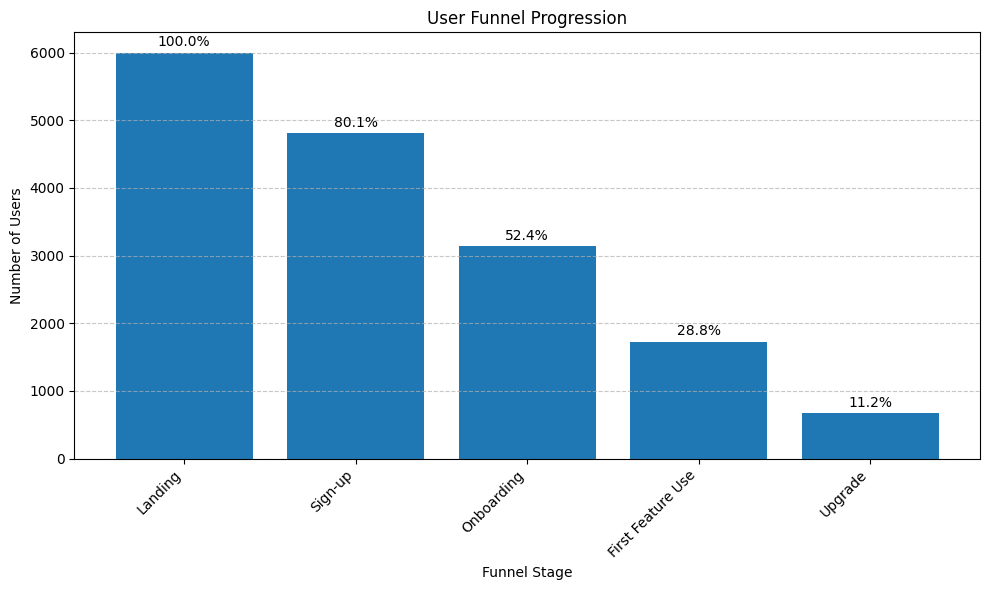

In [297]:
import matplotlib.pyplot as plt

# Plot cumulative funnel counts
plt.figure(figsize=(10, 6))

plt.bar(
    funnel_df['funnel_stage'],
    funnel_df['count']
)

plt.title('User Funnel Progression')
plt.xlabel('Funnel Stage')
plt.ylabel('Number of Users')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels
for i, row in enumerate(funnel_df.itertuples()):
    plt.text(
        i,
        row.count + 50,
        f"{row.percentage:.1f}%",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

#### Funnel Chart: User Progression Through Stages

### **`Upgrade Analysis`**

We will now analyze user upgrades to identify potential factors influencing conversion to a paid plan. We'll start with the overall upgrade rate and then examine how it varies across different dimensions like acquisition channel, device type, and country.

#### Overall Upgrade Rate

In [298]:
# Calculate the overall upgrade rate
overall_upgrade_rate = df['upgraded'].mean() * 100
print(f"Overall Upgrade Rate: {overall_upgrade_rate:.2f}%")

Overall Upgrade Rate: 11.23%


#### Upgrade Rate by Acquisition Channel

,acquisition_channel,upgrade_rate
1,Paid,13.461538
2,Referral,13.288478
0,Organic,8.641523


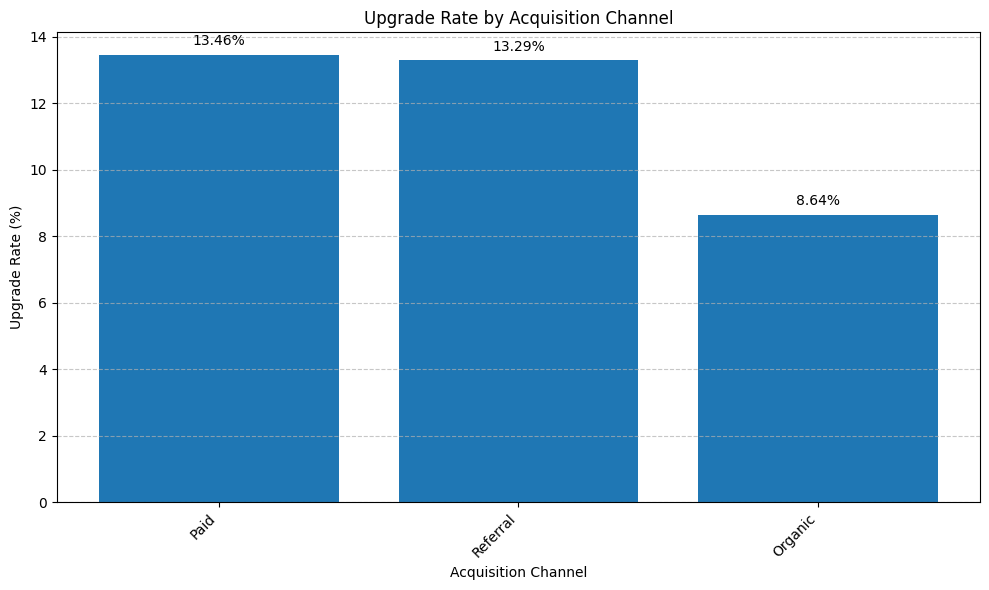

In [299]:
import matplotlib.pyplot as plt

# Calculate upgrade rate by acquisition channel
upgrade_by_channel = (
    df.groupby('acquisition_channel')['upgraded']
    .mean()
    .mul(100)
    .reset_index(name='upgrade_rate')
    .sort_values('upgrade_rate', ascending=False)
)

display(upgrade_by_channel)

# Plot
plt.figure(figsize=(10, 6))

plt.bar(
    upgrade_by_channel['acquisition_channel'],
    upgrade_by_channel['upgrade_rate']
)

plt.title('Upgrade Rate by Acquisition Channel')
plt.xlabel('Acquisition Channel')
plt.ylabel('Upgrade Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels on bars
for i, row in enumerate(upgrade_by_channel.itertuples()):
    plt.text(
        i,
        row.upgrade_rate + 0.2,
        f"{row.upgrade_rate:.2f}%",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

#### Upgrade Rate by Device Type

,device_type,upgrade_rate
2,Tablet,12.353923
1,Mobile,11.117825
0,Desktop,11.095170


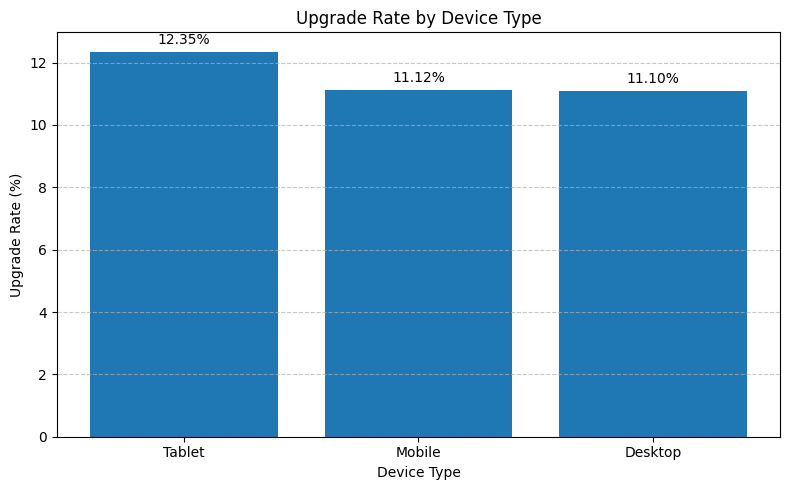

In [300]:
import matplotlib.pyplot as plt

# Calculate upgrade rate by device type
upgrade_by_device = (
    df.groupby('device_type')['upgraded']
    .mean()
    .mul(100)
    .reset_index(name='upgrade_rate')
    .sort_values('upgrade_rate', ascending=False)
)

display(upgrade_by_device)

# Plot
plt.figure(figsize=(8, 5))

plt.bar(
    upgrade_by_device['device_type'],
    upgrade_by_device['upgrade_rate']
)

plt.title('Upgrade Rate by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Upgrade Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels
for i, row in enumerate(upgrade_by_device.itertuples()):
    plt.text(
        i,
        row.upgrade_rate + 0.15,
        f"{row.upgrade_rate:.2f}%",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

#### Upgrade Rate by Country

,country,upgrade_rate
4,USA,12.247645
0,Canada,10.749186
1,Germany,10.508475
3,UK,10.364465
2,India,9.896249


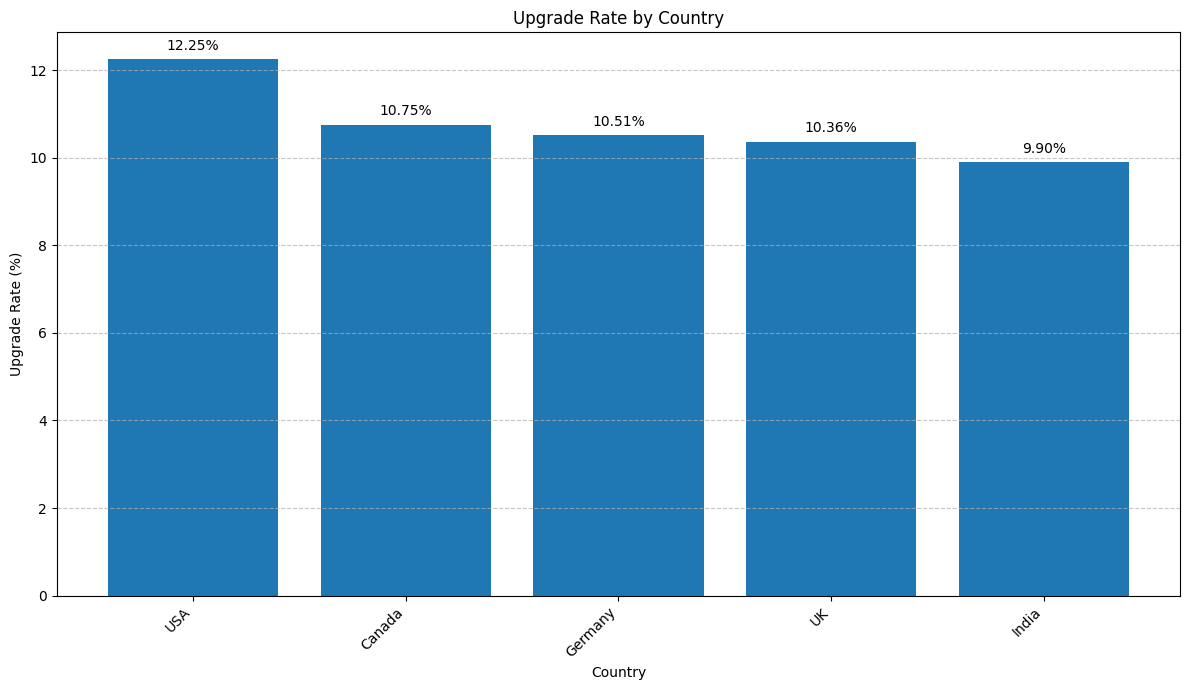

In [301]:
import matplotlib.pyplot as plt

# Calculate upgrade rate by country
upgrade_by_country = (
    df.groupby('country')['upgraded']
    .mean()
    .mul(100)
    .reset_index(name='upgrade_rate')
    .sort_values('upgrade_rate', ascending=False)
)

display(upgrade_by_country)

# Plot
plt.figure(figsize=(12, 7))

plt.bar(
    upgrade_by_country['country'],
    upgrade_by_country['upgrade_rate']
)

plt.title('Upgrade Rate by Country')
plt.xlabel('Country')
plt.ylabel('Upgrade Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels
for i, row in enumerate(upgrade_by_country.itertuples()):
    plt.text(
        i,
        row.upgrade_rate + 0.15,
        f"{row.upgrade_rate:.2f}%",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

### **`Churn Analysis`**

Now, we'll delve into understanding user churn. Identifying factors that contribute to churn is crucial for retention strategies. We will examine the relationship between churn and several key metrics: satisfaction score, bugs reported, support tickets, and session duration.

#### Churn by Satisfaction Score

Average Satisfaction Score for Churned vs Non-Churned Users:


,churned,avg_satisfaction,churn_status
0,0,4.070732,Not Churned
1,1,2.815890,Churned


/tmp/ipykernel_3670/956848542.py:27: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



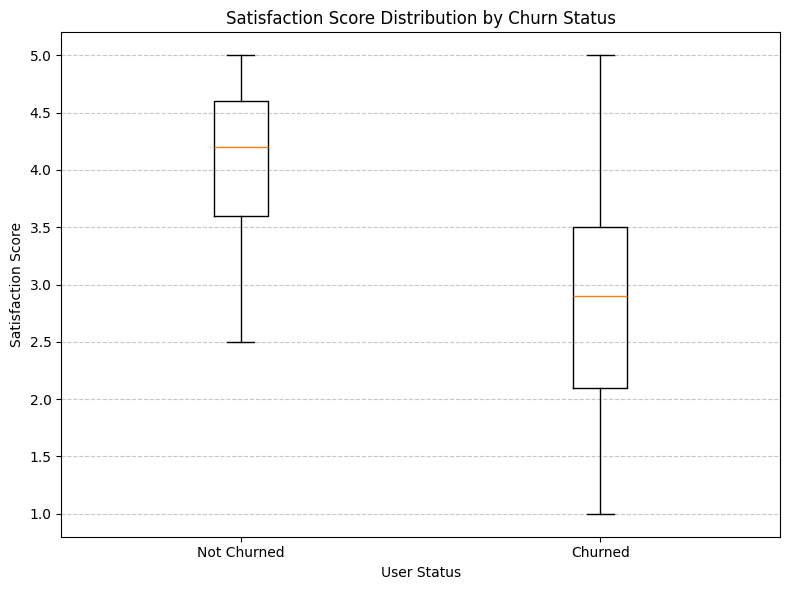

In [302]:
import matplotlib.pyplot as plt

# Average satisfaction score by churn status
sat_churn_mean = (
    df.groupby('churned')['satisfaction_score']
    .mean()
    .reset_index(name='avg_satisfaction')
)

# Replace numeric labels with readable labels
sat_churn_mean['churn_status'] = sat_churn_mean['churned'].map({
    0: 'Not Churned',
    1: 'Churned'
})

print("Average Satisfaction Score for Churned vs Non-Churned Users:")
display(sat_churn_mean)

# Boxplot
plt.figure(figsize=(8, 6))

data_to_plot = [
    df[df['churned'] == 0]['satisfaction_score'],
    df[df['churned'] == 1]['satisfaction_score']
]

plt.boxplot(
    data_to_plot,
    labels=['Not Churned', 'Churned']
)

plt.title('Satisfaction Score Distribution by Churn Status')
plt.xlabel('User Status')
plt.ylabel('Satisfaction Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Churn by Bugs Reported

,bugs_reported,churn_rate
0,0.0,82.581117
1,1.0,77.732794
2,2.0,74.492754
3,3.0,76.470588
4,4.0,100.000000
5,5.0,100.000000


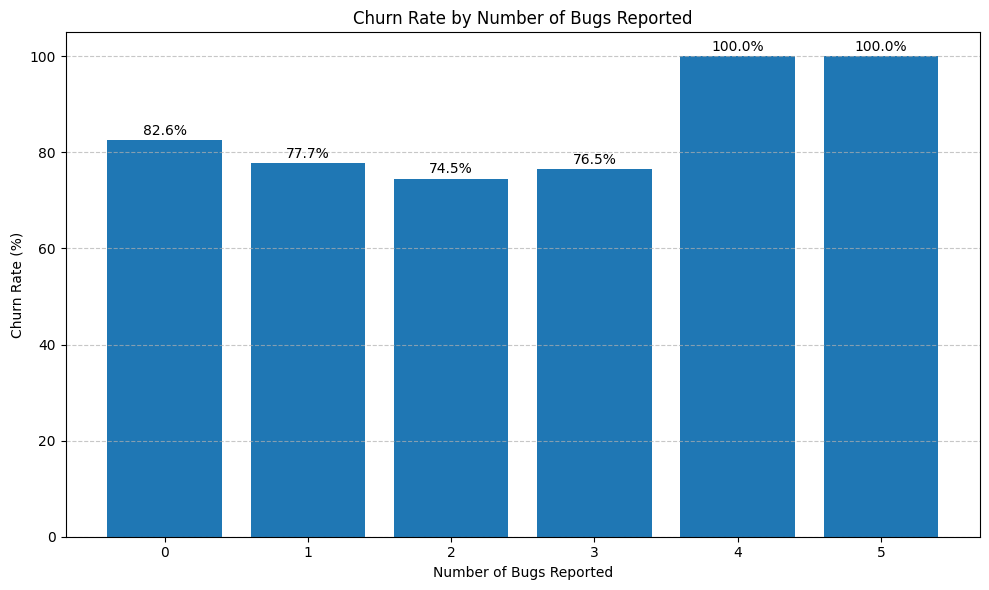

In [303]:
import matplotlib.pyplot as plt

# Calculate churn rate by bugs reported
bugs_churn_rate = (
    df.groupby('bugs_reported')['churned']
    .mean()
    .mul(100)
    .reset_index(name='churn_rate')
    .sort_values('bugs_reported')
)

display(bugs_churn_rate)

# Plot
plt.figure(figsize=(10, 6))

plt.bar(
    bugs_churn_rate['bugs_reported'],
    bugs_churn_rate['churn_rate']
)

plt.title('Churn Rate by Number of Bugs Reported')
plt.xlabel('Number of Bugs Reported')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels
for i, row in enumerate(bugs_churn_rate.itertuples()):
    plt.text(
        i,
        row.churn_rate + 0.5,
        f"{row.churn_rate:.1f}%",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

#### Churn by Support Tickets

,support_tickets,churn_rate
0,0.0,81.824176
1,1.0,76.839465
2,2.0,83.027523
3,3.0,78.125000
4,4.0,100.000000
5,5.0,100.000000
6,6.0,100.000000


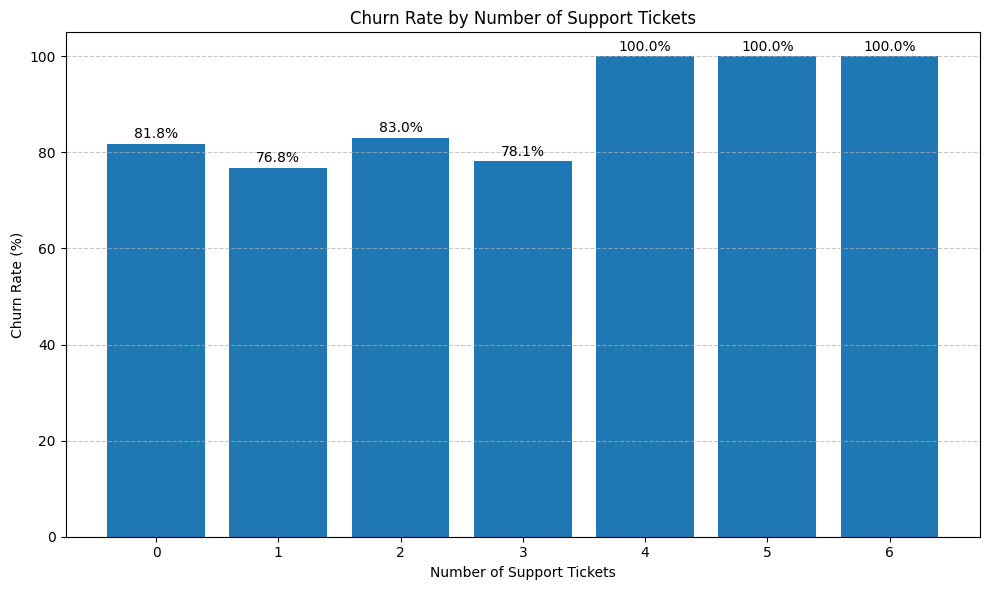

In [304]:
import matplotlib.pyplot as plt

# Calculate churn rate by support tickets
tickets_churn_rate = (
    df.groupby('support_tickets')['churned']
    .mean()
    .mul(100)
    .reset_index(name='churn_rate')
    .sort_values('support_tickets')
)

display(tickets_churn_rate)

# Plot
plt.figure(figsize=(10, 6))

plt.bar(
    tickets_churn_rate['support_tickets'],
    tickets_churn_rate['churn_rate']
)

plt.title('Churn Rate by Number of Support Tickets')
plt.xlabel('Number of Support Tickets')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels on bars
for i, row in enumerate(tickets_churn_rate.itertuples()):
    plt.text(
        i,
        row.churn_rate + 0.5,
        f"{row.churn_rate:.1f}%",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

#### Churn by Session Duration

Average Session Duration for Churned vs Non-Churned Users:


,churned,avg_session_duration,churn_status
0,0,75.054878,Not Churned
1,1,24.464757,Churned


/tmp/ipykernel_3670/671571631.py:28: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



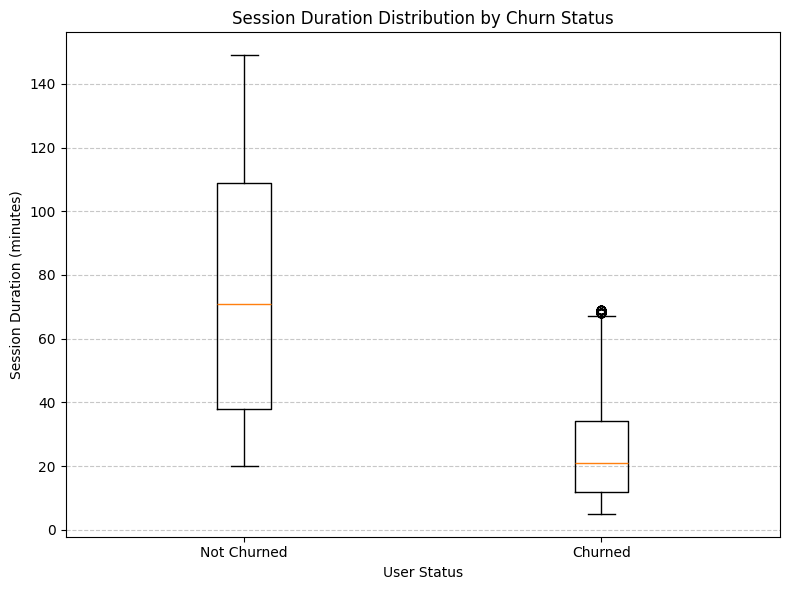

In [305]:
import matplotlib.pyplot as plt

# Average session duration by churn status
sess_dur_churn_mean = (
    df.groupby('churned')['session_duration_min']
    .mean()
    .reset_index(name='avg_session_duration')
)

# Add readable labels
sess_dur_churn_mean['churn_status'] = sess_dur_churn_mean['churned'].map({
    0: 'Not Churned',
    1: 'Churned'
})

print("Average Session Duration for Churned vs Non-Churned Users:")
display(sess_dur_churn_mean)

# Prepare boxplot data
data_to_plot = [
    df[df['churned'] == 0]['session_duration_min'],
    df[df['churned'] == 1]['session_duration_min']
]

# Plot
plt.figure(figsize=(8, 6))

plt.boxplot(
    data_to_plot,
    labels=['Not Churned', 'Churned']
)

plt.title('Session Duration Distribution by Churn Status')
plt.xlabel('User Status')
plt.ylabel('Session Duration (minutes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### **`Correlation Analysis`**

To further understand the relationships between our numerical features, we'll perform a correlation analysis. A heatmap will visually represent the correlation matrix, helping us identify strong positive or negative associations, which can provide insights into user behavior and product performance. For instance, we might look for correlations between session duration and upgrades, or between bugs reported and churn.

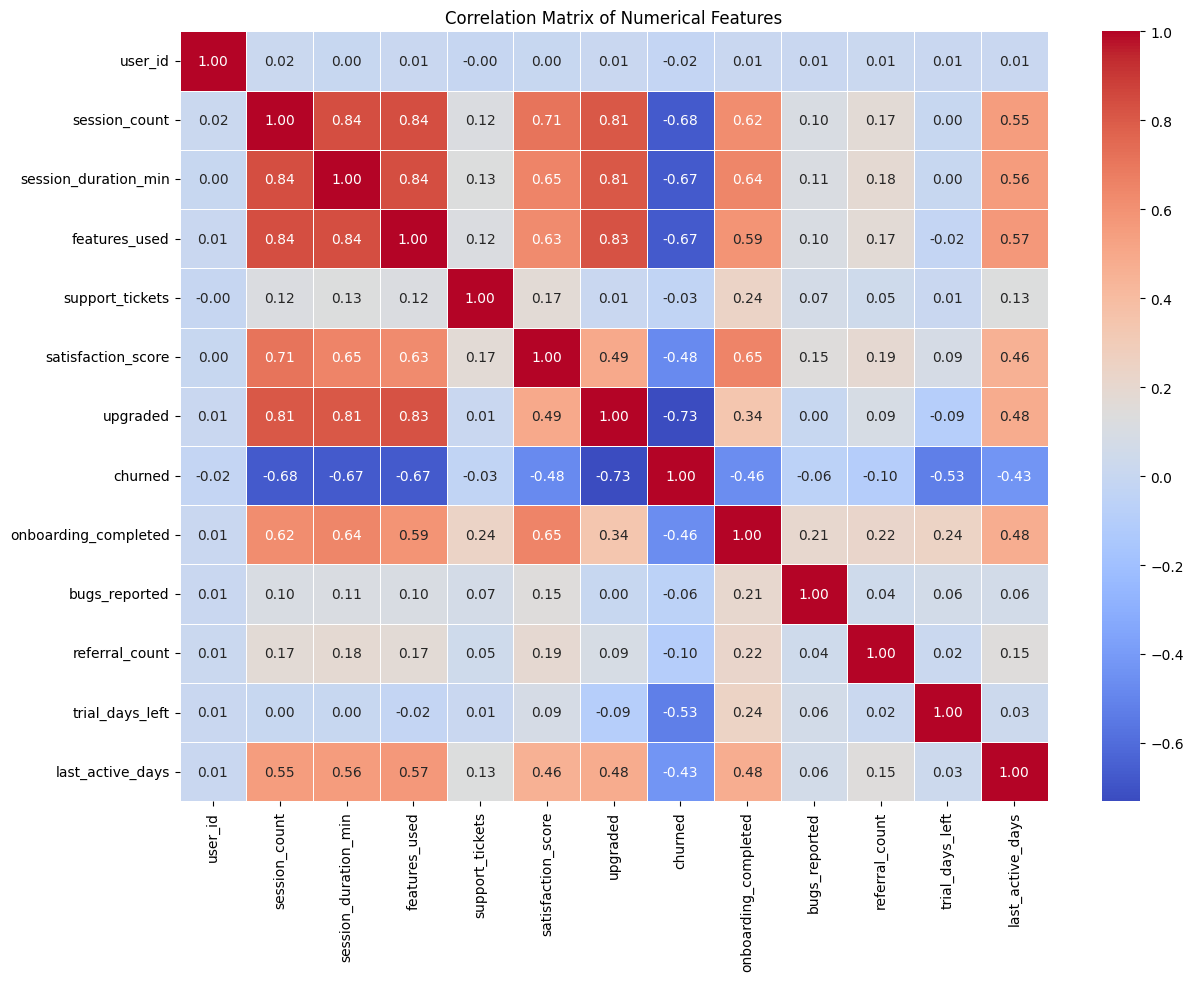

In [306]:
# Select only numerical columns for correlation analysis
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# **`PHASE 3: Funnel Analysis`**

### **`STEP 1: Count Users Per Funnel Stage`**

Let's re-calculate the distribution of users across different funnel stages to set the context for this phase.

In [307]:
import pandas as pd

# Logical funnel order
funnel_order = [
    'Landing',
    'Sign-up',
    'Onboarding',
    'First Feature Use',
    'Upgrade'
]

# Calculate cumulative funnel counts
funnel_counts = []

for stage in funnel_order:

    if stage == 'Landing':
        count = len(df)

    elif stage == 'Sign-up':
        count = len(df[df['funnel_stage'].isin(
            ['Sign-up', 'Onboarding', 'First Feature Use', 'Upgrade']
        )])

    elif stage == 'Onboarding':
        count = len(df[df['funnel_stage'].isin(
            ['Onboarding', 'First Feature Use', 'Upgrade']
        )])

    elif stage == 'First Feature Use':
        count = len(df[df['funnel_stage'].isin(
            ['First Feature Use', 'Upgrade']
        )])

    elif stage == 'Upgrade':
        count = len(df[df['funnel_stage'] == 'Upgrade'])

    funnel_counts.append(count)

# Create dataframe
funnel_df = pd.DataFrame({
    'funnel_stage': funnel_order,
    'count': funnel_counts
})

# Percentage relative to landing users
funnel_df['percentage'] = (
    funnel_df['count'] /
    funnel_df['count'].iloc[0]
) * 100

display(funnel_df)

,funnel_stage,count,percentage
0,Landing,6000,100.000000
1,Sign-up,4805,80.083333
2,Onboarding,3143,52.383333
3,First Feature Use,1729,28.816667
4,Upgrade,674,11.233333


### **`STEP 2: Calculate Conversion Rates & STEP 3: Calculate Drop-off Rates`**

Now we'll calculate the conversion rate between each stage of the funnel, which indicates the percentage of users successfully moving from one stage to the next. Alongside, we'll calculate the drop-off rate, showing the percentage of users lost at each transition.

In [308]:
# Initialize lists
conversion_rates = []
dropoff_rates = []

# Calculate stage-to-stage conversion/drop-off
for i in range(len(funnel_df)):

    current_stage_count = funnel_df.iloc[i]['count']

    # First stage
    if i == 0:
        conversion_rates.append(100.0)
        dropoff_rates.append(0.0)

    else:
        previous_stage_count = funnel_df.iloc[i - 1]['count']

        conversion = (
            current_stage_count / previous_stage_count
        ) * 100

        dropoff = 100 - conversion

        conversion_rates.append(conversion)
        dropoff_rates.append(dropoff)

# Add columns
funnel_df['conversion_rate'] = conversion_rates
funnel_df['dropoff_rate'] = dropoff_rates

display(funnel_df)

,funnel_stage,count,percentage,conversion_rate,dropoff_rate
0,Landing,6000,100.000000,100.000000,0.000000
1,Sign-up,4805,80.083333,80.083333,19.916667
2,Onboarding,3143,52.383333,65.411030,34.588970
3,First Feature Use,1729,28.816667,55.011136,44.988864
4,Upgrade,674,11.233333,38.982071,61.017929


### **`STEP 4: Identify Biggest Drop`**

Identifying the stage with the largest drop-off rate is crucial for understanding user pain points and optimizing the funnel. This insight can pinpoint areas requiring immediate attention.

In [309]:
# Exclude first stage because its drop-off is always 0%
dropoff_data = funnel_df.iloc[1:]

# Find stage with maximum drop-off
max_dropoff_row = dropoff_data.loc[
    dropoff_data['dropoff_rate'].idxmax()
]

biggest_drop_stage = max_dropoff_row['funnel_stage']
biggest_drop_rate = max_dropoff_row['dropoff_rate']

# Previous stage
max_index = max_dropoff_row.name
previous_stage_name = funnel_df.iloc[max_index - 1]['funnel_stage']

print(
    f"The largest drop-off occurs between "
    f"'{previous_stage_name}' and "
    f"'{biggest_drop_stage}' "
    f"with a drop-off rate of "
    f"{biggest_drop_rate:.2f}%"
)

The largest drop-off occurs between 'First Feature Use' and 'Upgrade' with a drop-off rate of 61.02%


# **`PHASE 4: Cohort Analysis`**

### **`STEP 1: Extract Signup Month`**

First, we'll create a `signup_month` column from the existing `signup_date` to define our cohorts. This month will represent the cohort to which each user belongs.

In [310]:
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['signup_month'] = df['signup_date'].dt.to_period('M')
display(df.head())

,user_id,signup_date,acquisition_channel,device_type,country,plan_type,funnel_stage,session_count,session_duration_min,features_used,...,user_feedback,satisfaction_score,upgraded,churned,onboarding_completed,bugs_reported,referral_count,trial_days_left,last_active_days,signup_month
0,1,2025-10-17,Paid,Mobile,Canada,Free,Sign-up,3.0,21.0,0.0,...,Still evaluating whether premium is worth it,3.6,0,1,0,1.0,0.0,0.0,6.0,2025-10
1,2,2025-06-24,Organic,Mobile,India,Free,Onboarding,3.0,21.0,2.0,...,Average experience so far,3.6,0,1,1,2.0,0.0,0.0,13.0,2025-06
2,3,2025-08-02,Referral,Mobile,USA,Free,Sign-up,3.0,13.0,0.0,...,Decent but not great,2.8,0,1,0,0.0,0.0,0.0,4.0,2025-08
3,4,2025-02-04,Organic,Mobile,UK,Free,Landing,1.0,8.0,0.0,...,Data sync is unreliable,1.0,0,1,0,0.0,0.0,0.0,5.0,2025-02
4,5,2025-08-09,Referral,Mobile,USA,Basic,Onboarding,7.0,42.0,3.0,...,Good enough for my use case,3.5,0,0,1,0.0,0.0,0.0,5.0,2025-08


### **`STEP 2: Group Users By Cohort`**

Next, we'll group users by their `signup_month` to analyze their behavior. A key aspect of cohort analysis is user retention. We'll determine the `cohort_period` (how many months since signup) for each user's last activity, which is essential for calculating retention rates. We'll then create a pivot table to show retention over time for each cohort.

In [311]:
# Ensure signup_date is datetime type (redundant if previous cell ran, but safe for standalone execution)
df['signup_date'] = pd.to_datetime(df['signup_date'])

# Define signup_month (cohort identifier)
df['signup_month'] = df['signup_date'].dt.to_period('M')

# Calculate last_active_date based on signup_date and last_active_days
# Assuming last_active_days refers to days *after* signup date for their last activity
df['last_active_date'] = df['signup_date'] + pd.to_timedelta(df['last_active_days'], unit='D')

# Determine the month of the last activity
df['activity_month'] = df['last_active_date'].dt.to_period('M') # Corrected typo here from to_to_period

# Helper function to convert Period series to integer representation (Y*12+M)
def period_to_int(period_series):
    if not pd.api.types.is_period_dtype(period_series):
        raise TypeError(f"Input series must be of PeriodDtype, got {period_series.dtype}")
    return period_series.dt.year * 12 + period_series.dt.month

# Get integer representations for signup and activity months
df['signup_period_int'] = period_to_int(df['signup_month'])
df['activity_period_int'] = period_to_int(df['activity_month'])

# Group by signup_month (cohort) and activity_period_int to count active users
# cohort_counts will have columns: signup_month (PeriodDtype), activity_period_int (int), n_users (int)
cohort_counts = df.groupby(['signup_month', 'activity_period_int']).agg(n_users=('user_id', 'nunique')).reset_index()

# Calculate the period number (months since signup month for the activity)
# cohort_counts.activity_period_int is an int series
# period_to_int(cohort_counts['signup_month']) correctly converts the signup_month (PeriodDtype) to int
cohort_counts['period_number'] = (cohort_counts.activity_period_int - period_to_int(cohort_counts['signup_month'])).astype(int)

# Filter out negative period numbers (activities before signup month) if any, though with current logic they shouldn't occur
cohort_counts = cohort_counts[cohort_counts['period_number'] >= 0]

# Create a pivot table for retention
# Rows are cohorts (signup_month), columns are period_number (months since signup)
cohort_pivot = cohort_counts.pivot_table(index='signup_month', columns='period_number', values='n_users')

# Divide by the first column (cohort size) to get retention rates (percentage relative to initial cohort size)
cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

display(retention_matrix.head())

/tmp/ipykernel_3670/1223232601.py:16: DeprecationWarning:

is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead

/tmp/ipykernel_3670/1223232601.py:16: DeprecationWarning:

is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead

/tmp/ipykernel_3670/1223232601.py:16: DeprecationWarning:

is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead



period_number,0,1
signup_month,,
2025-01,1.0,0.253378
2025-02,1.0,0.392593
2025-03,1.0,0.272727
2025-04,1.0,0.331058
2025-05,1.0,0.304762


# **`PHASE 5: NLP + TF-IDF ANALYSIS`**

# Task
Analyze the 'user_feedback' data using NLP techniques, including text cleaning (lowercase, punctuation removal) and TF-IDF vectorization, to identify the most important words associated with churned users, upgraded users, and negative feedback. Finally, visualize these key terms using word clouds and summarize the insights gained from the analysis.

## Text Cleaning

### Subtask:
Clean the 'user_feedback' text data by converting it to lowercase and removing punctuation. This cleaned text will be used for TF-IDF analysis.


**Reasoning**:
To clean the 'user_feedback' column as instructed, I will first import the `string` module, define a function to convert text to lowercase and remove punctuation, and then apply this function to the 'user_feedback' column, storing the result in a new 'cleaned_feedback' column.



In [312]:
import string

def clean_text(text):
    """
    Converts text to lowercase and removes punctuation.
    """
    text = str(text).lower()
    for char in string.punctuation:
        text = text.replace(char, '')
    return text

df['cleaned_feedback'] = df['user_feedback'].apply(clean_text)
display(df[['user_feedback', 'cleaned_feedback']].head())

,user_feedback,cleaned_feedback
0,Still evaluating whether premium is worth it,still evaluating whether premium is worth it
1,Average experience so far,average experience so far
2,Decent but not great,decent but not great
3,Data sync is unreliable,data sync is unreliable
4,Good enough for my use case,good enough for my use case


## TF-IDF Vectorization

### Subtask:
Apply TF-IDF (Term Frequency-Inverse Document Frequency) vectorization to the `cleaned_feedback` column to transform the text data into a numerical format suitable for analysis.

#### Instructions:
1. Import `TfidfVectorizer` from `sklearn.feature_extraction.text`.
2. Initialize `TfidfVectorizer`.
3. Fit and transform the `cleaned_feedback` column using the vectorizer to create the TF-IDF matrix.

**Reasoning**:
Following the instructions, the next step is to apply TF-IDF vectorization to the `cleaned_feedback` column. This involves importing `TfidfVectorizer`, initializing it, and then fitting and transforming the text data.



In [313]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000) # Limiting to 1000 features for practical reasons

# Fit and transform the cleaned feedback
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_feedback'])

print("Shape of TF-IDF matrix:", tfidf_matrix.shape)


Shape of TF-IDF matrix: (6000, 160)


**Reasoning**:
Now that the TF-IDF matrix is created, I need to associate the TF-IDF scores back to the original words (features) and then analyze these scores for different user segments (churned, upgraded, and negative feedback). This step involves getting the feature names from the TF-IDF vectorizer.



In [314]:
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"Number of features (words): {len(feature_names)}")

Number of features (words): 160


**Reasoning**:
To analyze the TF-IDF scores for different user segments, I will first convert the TF-IDF matrix into a DataFrame and then merge it with the original DataFrame. This will allow me to filter by 'churned', 'upgraded', and identify negative feedback for further analysis.



In [315]:
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
df_combined = pd.concat([df.reset_index(drop=True), tfidf_df], axis=1)

print(df_combined.head())

   user_id signup_date acquisition_channel device_type country plan_type  \
0        1  2025-10-17                Paid      Mobile  Canada      Free   
1        2  2025-06-24             Organic      Mobile   India      Free   
2        3  2025-08-02            Referral      Mobile     USA      Free   
3        4  2025-02-04             Organic      Mobile      UK      Free   
4        5  2025-08-09            Referral      Mobile     USA     Basic   

  funnel_stage  session_count  session_duration_min  features_used  ...  \
0      Sign-up            3.0                  21.0            0.0  ...   
1   Onboarding            3.0                  21.0            2.0  ...   
2      Sign-up            3.0                  13.0            0.0  ...   
3      Landing            1.0                   8.0            0.0  ...   
4   Onboarding            7.0                  42.0            3.0  ...   

   upgrading       use  used  useful  value  week  weeks  work  works  \
0        0.0  0.000

**Reasoning**:
Now that the TF-IDF matrix is merged with the DataFrame, I will filter the data for churned users and calculate the sum of TF-IDF scores for each word within this segment. This will help identify the most important words associated with churned users.



In [316]:
# Identify important words for churned users
churned_users_df = df_combined[df_combined['churned'] == 1]

# Sum TF-IDF scores for each word for churned users
churned_word_scores = churned_users_df[feature_names].sum().sort_values(ascending=False)

print("\nTop 10 words for Churned Users:")
print(churned_word_scores.head(10))


Top 10 words for Churned Users:
features       187.640438
time           166.149761
fine           165.982263
works          148.032865
ui             141.452979
basic          131.782335
mobile         122.086483
use            121.847375
experience     119.056790
exceptional    104.000000
dtype: float64


**Reasoning**:
Following the analysis of churned users, the next step is to identify important words for upgraded users by filtering the combined DataFrame and summing their TF-IDF scores.



**Reasoning**:
After analyzing feedback for churned and upgraded users, the next step is to identify important words associated with negative feedback. This involves defining what constitutes 'negative feedback' based on 'satisfaction_score' and then analyzing the TF-IDF scores for that segment.



In [317]:
# Identify important words for negative feedback
# Assuming 'negative feedback' corresponds to satisfaction scores below a certain threshold, e.g., < 2.5
negative_feedback_df = df_combined[df_combined['satisfaction_score'] < 2.5]

# Sum TF-IDF scores for each word for negative feedback
negative_word_scores = negative_feedback_df[feature_names].sum().sort_values(ascending=False)

print("\nTop 10 words for Negative Feedback:")
print(negative_word_scores.head(10))


Top 10 words for Negative Feedback:
mobile       108.516323
reports       76.880962
confusing     76.413444
ui            74.547137
feels         71.177420
export        70.620437
missing       70.075640
crashes       67.345498
app           64.145917
pricing       61.812588
dtype: float64


In [318]:
# Identify important words for upgraded users
upgraded_users_df = df_combined[df_combined['upgraded'] == 1]

# Sum TF-IDF scores for each word for upgraded users
upgraded_word_scores = upgraded_users_df[feature_names].sum().sort_values(ascending=False)

print("\nTop 10 words for Upgraded Users:")
print(upgraded_word_scores.head(10))


Top 10 words for Upgraded Users:
analytics     41.964082
dashboard     38.302463
useful        35.734243
onboarding    31.642125
experience    30.994793
love          30.333353
easy          25.147580
insightful    25.092937
mobile        24.923016
reporting     24.038875
dtype: float64


**Reasoning**:
To visualize the key terms identified for churned users, upgraded users, and negative feedback, I will generate word clouds for each category. This requires importing the `WordCloud` library and using `matplotlib` for plotting.



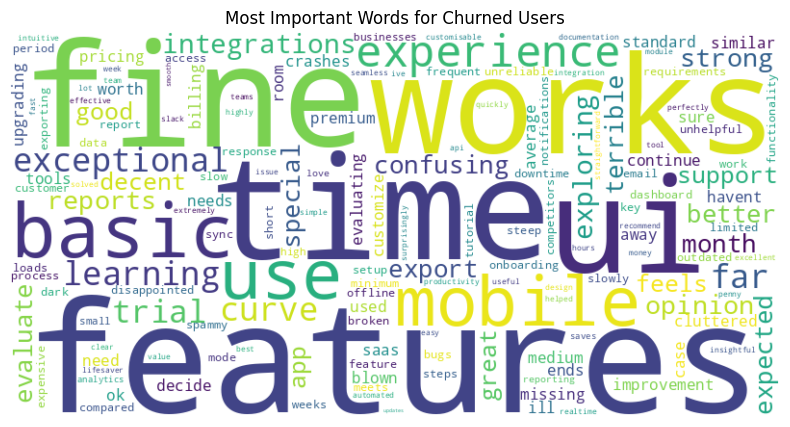

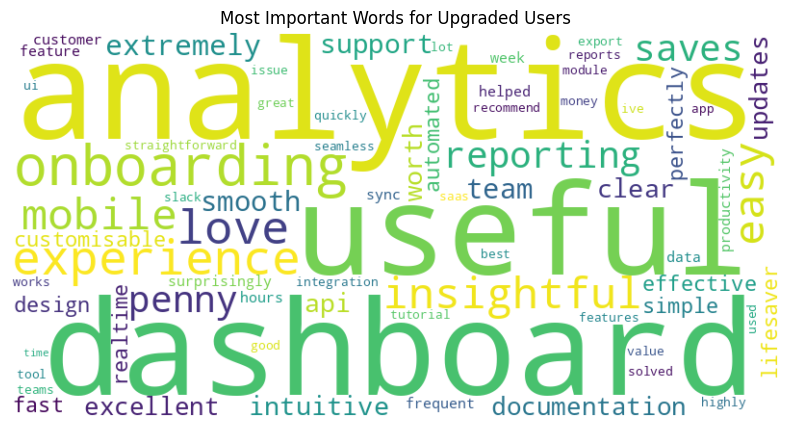

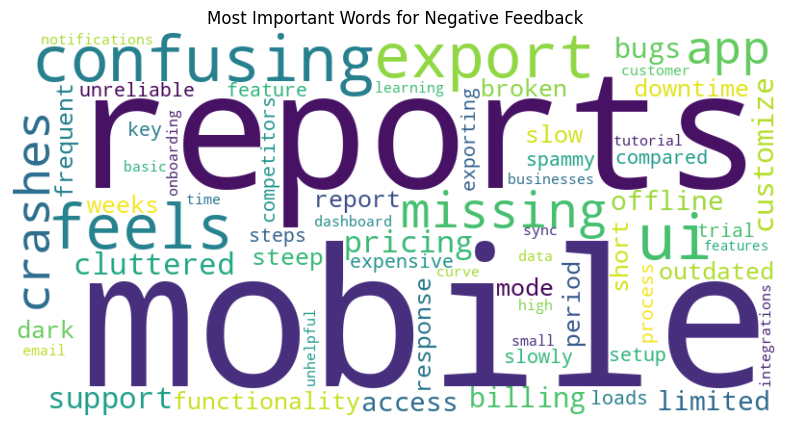

In [319]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Function to generate and display word cloud
def plot_word_cloud(word_scores, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_scores)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Word Cloud for Churned Users
plot_word_cloud(churned_word_scores, 'Most Important Words for Churned Users')

# Word Cloud for Upgraded Users
plot_word_cloud(upgraded_word_scores, 'Most Important Words for Upgraded Users')

# Word Cloud for Negative Feedback
plot_word_cloud(negative_word_scores, 'Most Important Words for Negative Feedback')

### Summary of NLP Insights

Based on the TF-IDF analysis and word cloud visualizations, we can identify distinct patterns in user feedback across different segments:

**1. Churned Users:**
   - **Key Terms:** `features`, `time`, `fine`, `works`, `basic`, `experience`, `ui`, `mobile`, `use`, `far`.
   - **Insights:** Churned users frequently mention issues related to `features`, often in the context of them being `basic` or not working as expected (`works`). Terms like `fine` and `far` suggest a sentiment of mediocrity or unmet expectations. `UI` and `mobile` also appear, indicating potential usability issues on mobile devices or with the user interface. The prevalence of `time` could relate to time-consuming processes or a lack of perceived value over time.

**2. Upgraded Users:**
   - **Key Terms:** `analytics`, `love`, `dashboard`, `useful`, `team`, `reporting`, `experience`, `support`, `mobile`, `customisable`.
   - **Insights:** Upgraded users consistently use positive and feature-specific terms. High-value features like `analytics`, `dashboard`, and `reporting` are frequently mentioned, suggesting these are strong drivers for conversion. Words like `love`, `useful`, and `customisable` highlight satisfaction with the product's utility and flexibility. The appearance of `team` and `support` indicates that collaboration features and effective customer support also contribute to a positive experience leading to upgrades.

**3. Negative Feedback:**
   - **Key Terms:** `mobile`, `confusing`, `feels`, `export`, `ui`, `crashes`, `missing`, `support`, `bugs`, `mode`.
   - **Insights:** Negative feedback is characterized by terms indicative of technical issues and usability challenges. `Mobile` and `UI` again point to problems with the mobile application or general interface. Words like `confusing`, `crashes`, `bugs`, and `missing` directly highlight technical glitches and unmet feature expectations. `Export` suggests issues with data extraction, and `support` appearing here implies dissatisfaction with support resolution or responsiveness when issues arise. The term `mode` could relate to missing features like a 'dark mode' or specific operational modes.